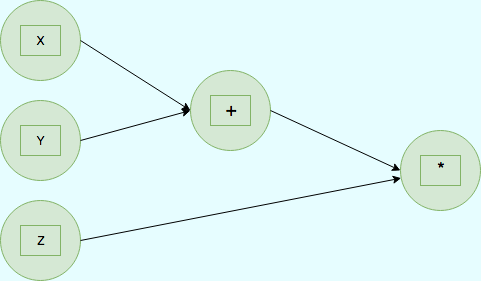

## Implement a Computational Graph Node Class

**Goal:** Implement a `Node` class to represent values in a computational graph, supporting element-wise arithmetic operations and tracking dependencies for automatic differentiation.

### Task Breakdown:

1.  **Define the `Node` class:**
    *   **Attributes:**
        *   `value`: Stores the numerical value (NumPy array).
        *   `children`: Tracks dependencies (other `Node` objects used to compute the current node).
        *   `op`: Stores the operation that created the node (e.g., "add", "mul").
        *   `op_args`: Stores additional operation-related constants if needed.

2.  **Overload Arithmetic Operators:**
    *   Support element-wise operations between `Node` objects and constants for:
        *   Addition (+)
        *   Subtraction (-)
        *   Multiplication (*)
        *   Division (/)
        *   Exponentiation (**)

3.  **Track Dependencies in the Computation Graph:**
    *   If an operation involves two `Node` objects, store both as `children`.
    *   If an operation involves a constant, store only the `Node` operand.
    *   *Example:* For `a = (x+y)*z`, let `b = x+y`.
        *   `b` and `z` are `children` of `a`.
        *   `x` and `y` are `children` of `b`.

4.  **Implement `backward()` method for gradient computation:**
    *   **Purpose:** Compute gradients using the chain rule, propagating them correctly through the computation graph from the output node to its dependencies.
    *   **Initialization:** Initialize `grad` to 1 if the node is the starting point of backpropagation.
    *   **Propagation:** Propagate gradients recursively to all dependent nodes (`children`) based on the operation performed.

5.  **Implement Gradient Calculations for Operations:**
    *   **Addition (+):** Gradient is passed unchanged to both operands.
    *   **Subtraction (-):** Left operand receives `grad`, right operand receives `-grad`.
    *   **Multiplication (*):** Uses the product rule.
    *   **Division (/):** Uses the quotient rule.
    *   **Exponentiation (**):** Uses the power rule and logarithm differentiation.

6.  **Perform Backpropagation:**
    *   Compute gradients by calling `backward()` from the final output node.
    *   Ensure gradients accumulate correctly when a node is used in multiple operations.

7.  **Verify Correctness (Example):**
    *   Create two `Node` objects (e.g., `a` and `b`) initialized with NumPy arrays.
    *   Compute intermediate and final results:
        *   `c = a × 2 + b`
        *   `d = c^3`
    *   Call `d.backward()` to compute the gradient of `d` with respect to `a`, `b`, and `c`.
    *   Print the computed gradients.

In [21]:
import numpy as np

In [22]:
class Node:
  def __init__(self,value,children = None,op = "",op_args = None):
    self.value = np.atleast_1d(np.array(value, dtype=float))
    self.children = children if children is not None else ()
    self.op = op
    self.op_args = op_args
    self.grad = np.zeros_like(self.value,dtype=float)

  def __add__(self,other):
    other = other if isinstance(other,Node) else Node(other)
    out = Node(self.value + other.value,children = (self,other),op = "add")
    return out

  def __radd__(self,other):
    return self.__add__(other)

  def __sub__(self,other):
    other = other if isinstance(other,Node) else Node(other)
    out = Node(self.value - other.value,children = (self,other),op = "sub")
    return out

  def __rsub__(self, other):
    other = other if isinstance(other, Node) else Node(other)
    return other.__sub__(self)

  def __mul__(self,other):
    other = other if isinstance(other,Node) else Node(other)
    out = Node(self.value * other.value,children = (self,other),op = "mult")
    return out

  def __rmul__(self,other):
    return self.__mul__(other)

  def __truediv__(self,other):
    other = other if isinstance(other,Node) else Node(other)
    out = Node(self.value / other.value,children = (self,other),op = "div")
    return out

  def __rtruediv__(self, other):
    other = other if isinstance(other, Node) else Node(other)
    return other.__truediv__(self)

  def __pow__(self,other):
    other = other if isinstance(other,Node) else Node(other)
    out = Node(self.value ** other.value,children = (self,other),op = "pow")
    return out

  def backward(self,grad = None):
    if grad is None:
      grad = np.ones_like(self.value,dtype=float)

    self.grad += grad
    op = self.op

    if op is None or not self.children:
      return

    if self.op == "add":
      a,b = self.children
      a.backward(grad)
      b.backward(grad)

    elif self.op == "sub":
      a,b = self.children
      a.backward(grad)
      b.backward(-grad)

    elif self.op == "mult":
      a,b = self.children
      a.backward(grad * b.value)
      b.backward(grad * a.value)

    elif self.op == "div":
      a,b = self.children
      a.backward(grad / b.value)
      b.backward(-grad * a.value / (b.value ** 2))

    elif self.op == "pow":
      a,b = self.children
      a.backward(grad * b.value * (a.value ** (b.value - 1)))
      b.backward(grad * np.log(a.value) * (a.value ** b.value))

    else:
      raise Exception(f"Unsupported operation: {self.op}")

    return self.grad



In [24]:
a = Node(np.array([2.0]))
b = Node(np.array([3.0]))

c = a * 2 + b
d = c ** 3

d.backward()
print(a.grad)
print(b.grad)

[294.]
[147.]
